In [1]:
import pandas as pd

dataframe = pd.read_csv("../data/snsdata.csv")
dataframe.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [2]:
dataframe.shape

(30000, 40)

In [3]:
# Faltantes: solo edad y genero

dataframe.isna().sum()[lambda s: s > 0]

gender    2724
age       5086
dtype: int64

In [4]:
# El genero faltante se conserva como categoria propia

dataframe["gender"].value_counts(dropna=False)

gender
F      22054
M       5222
NaN     2724
Name: count, dtype: int64

In [5]:
# La edad tiene valores no creibles (3 y 106 anos) para estudiantes de secundaria

dataframe["age"].describe()

count    24914.000000
mean        17.993950
std          7.858054
min          3.086000
25%         16.312000
50%         17.287000
75%         18.259000
max        106.927000
Name: age, dtype: float64

In [6]:
# Edades fuera de [13, 20) se marcan como faltantes y se imputan con la
# media de su ano de graduacion, que es un buen indicador de la edad

edad = dataframe["age"].where(dataframe["age"].between(13, 20, inclusive="left"))
print("edades faltantes tras el filtro:", edad.isna().sum())

edad.groupby(dataframe["gradyear"]).mean()

edades faltantes tras el filtro: 5523


gradyear
2006    18.655858
2007    17.706172
2008    16.767701
2009    15.819573
Name: age, dtype: float64

In [7]:
# Los 36 terminos de interes: conteos muy sesgados, casi todo ceros

intereses = list(dataframe.columns[dataframe.columns.get_loc("friends") + 1:])

print("terminos:", len(intereses))
print("proporcion de ceros:", round((dataframe[intereses] == 0).to_numpy().mean(), 3))
print("perfiles sin ningun termino:", round((dataframe[intereses].sum(axis=1) == 0).mean(), 3))

dataframe[intereses].describe().loc[["mean", "50%", "max"]].T.sort_values("mean", ascending=False).head(8)

terminos: 36
proporcion de ceros: 0.879
perfiles sin ningun termino: 0.082


,mean,50%,max
music,0.737833,0.0,64.0
god,0.465300,0.0,79.0
dance,0.425167,0.0,30.0
hair,0.422567,0.0,37.0
shopping,0.353000,0.0,11.0
cute,0.322867,0.0,18.0
band,0.299600,0.0,66.0
basketball,0.267333,0.0,24.0


In [8]:
# Con los conteos crudos estandarizados, los valores extremos dominan:
# aparecen grupos de un solo perfil. Con log(1 + x) antes de estandarizar
# el problema desaparece.

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

crudo = StandardScaler().fit_transform(dataframe[intereses])
logaritmo = StandardScaler().fit_transform(np.log1p(dataframe[intereses]))

for nombre, matriz in [("crudo", crudo), ("log1p", logaritmo)]:
    etiquetas = KMeans(5, n_init=10, random_state=42).fit_predict(matriz)
    print(nombre, sorted(np.bincount(etiquetas), reverse=True))

crudo [22823, 5412, 1093, 671, 1]


log1p [18765, 7477, 1513, 1441, 804]


In [9]:
# Seleccion de k: inercia y silhouette sobre la matriz log1p

import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

ks = range(2, 10)
inercias, siluetas = [], []

for k in ks:
    kmeans = KMeans(k, n_init=10, random_state=42).fit(logaritmo)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(logaritmo, kmeans.labels_, sample_size=5000, random_state=0))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(ks, inercias, marker="o")
axes[0].set_title("Inercia")
axes[1].plot(ks, siluetas, marker="o")
axes[1].set_title("Silhouette")
for ax in axes:
    ax.set_xlabel("k")
plt.show()

<Figure size 1000x350 with 2 Axes>

In [10]:
# Ni la inercia ni el silhouette muestran un codo claro (los datos no
# forman grupos compactos). Se elige k = 5 por interpretabilidad: cada
# segmento tiene un conjunto de intereses propio. Con k = 6 el unico
# cambio es que "bible" se separa en un grupo de ~460 perfiles.

import sys

sys.path.insert(0, "../src")

import segmentation

segmentado = segmentation.main()

 cluster     n  mujeres  edad  amigos  palabras                               terminos
       0 18765     0.68 17.32   16.00      3.00                 ninguno sobre la media
       1  7477     0.83 17.11   27.00     11.00      church, god, shopping, basketball
       2  1513     0.85 16.90   31.00     11.00 hollister, abercrombie, shopping, mall
       3  1441     0.83 17.08   20.00     21.00               kissed, sex, drugs, hair
       4   804     0.73 17.39   24.00     10.00            marching, band, music, rock


Resultados guardados en C:\Users\danie\dev\Analitica Predictiva\std-daniel-gonzalez-henao\PRE_06_clustering_mercadeo\submission


In [11]:
# Los segmentos, de mayor a menor:
#
#   1. Poca actividad: mediana de 3 palabras de interes, pocos amigos.
#   2. Activos generales: todo un poco por encima de la media, con acento
#      en religion, compras y deportes.
#   3. Marcas de ropa: hollister, abercrombie, shopping, mall.
#   4. Conductas de riesgo: kissed, sex, drugs, drunk; los que mas escriben.
#   5. Banda de marcha: marching, band, music.

segmentado.groupby("cluster").agg(
    perfiles=("cluster", "size"),
    mujeres=("gender", lambda s: (s == "F").mean()),
    edad=("age", "mean"),
    amigos=("friends", "median"),
).round(2)

,perfiles,mujeres,edad,amigos
cluster,,,,
0,18765,0.68,17.32,16.0
1,7477,0.83,17.11,27.0
2,1513,0.85,16.90,31.0
3,1441,0.83,17.08,20.0
4,804,0.73,17.39,24.0


In [12]:
# El genero cambia entre segmentos: poca actividad y banda de marcha tienen
# la mayor proporcion de hombres (21%), y poca actividad concentra ademas
# los perfiles sin genero (11%)

pd.crosstab(segmentado["cluster"], segmentado["gender"], normalize="index").round(2)

gender,F,M,NA
cluster,,,
0,0.68,0.21,0.11
1,0.83,0.11,0.06
2,0.85,0.07,0.08
3,0.83,0.12,0.06
4,0.73,0.21,0.06


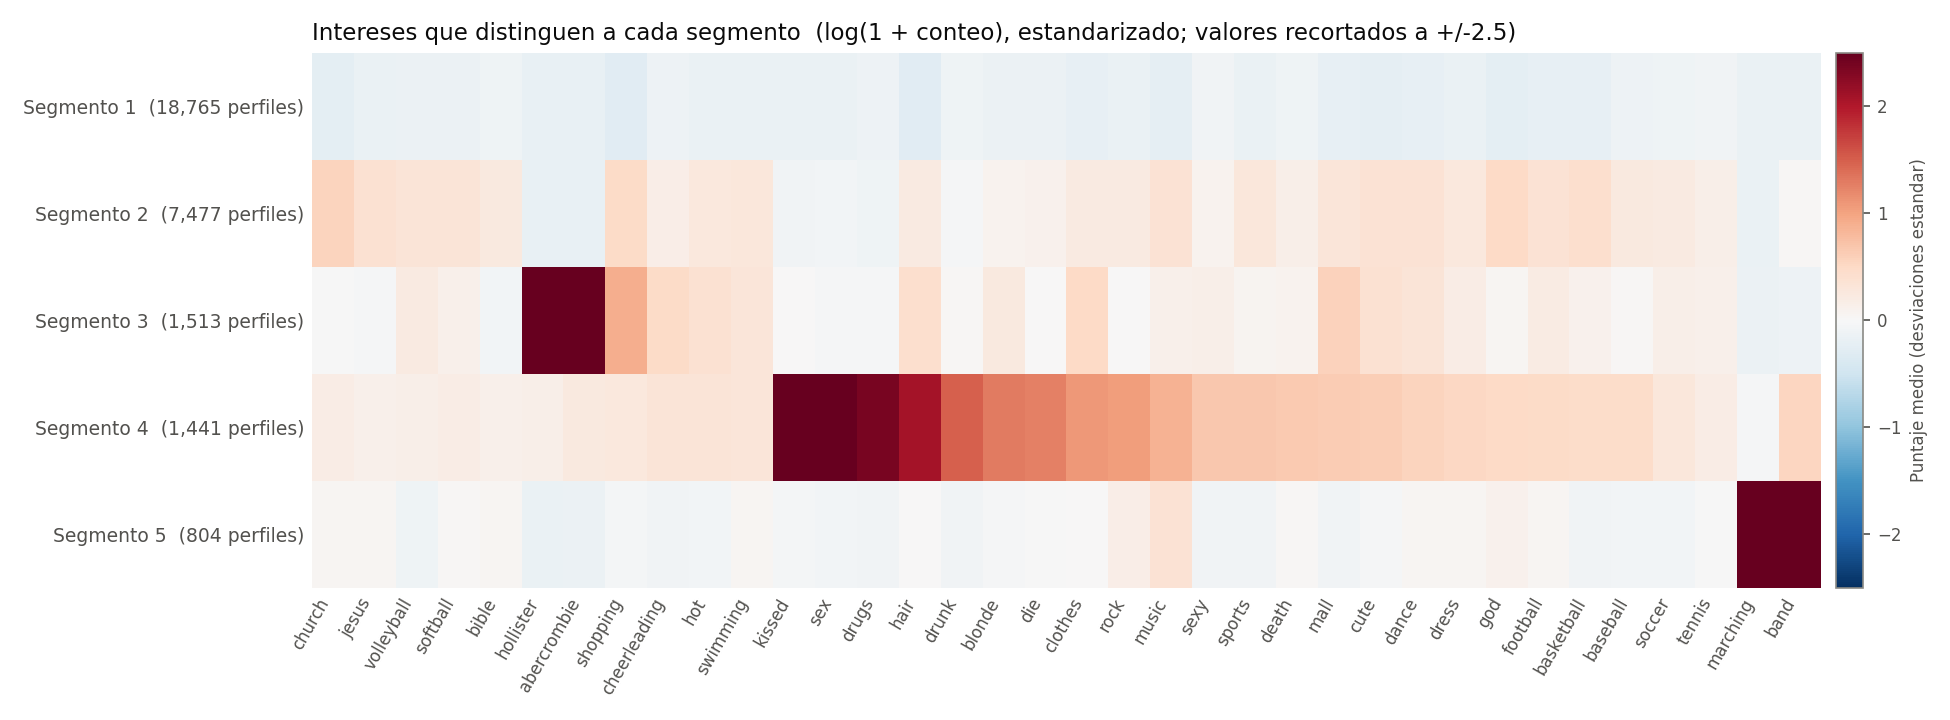

In [13]:
from IPython.display import Image

Image("../submission/segmentos-perfiles.png")